###### 129_7_site_summary_qcut_graph_practice.ipynb

In [1]:
#cell1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#cell2
plt.rcParams["font.family"] = "Meiryo"

In [3]:
df = pd.DataFrame(
       {
        "site": [
            "SUS",
            "SUS",
            "SUS",
            "WSE",
            "WSE",
            "WSE",
            "GSE",
            "GSE",
            "GSE",
            "MELMB",
            "MELMB",
            "MELMB",
            "ISE",
            "ISE",
            "ISE",
            "SMEO",
            "SMEO",
            "SMEO",
        ],
        "model": [
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
        ],
        "defect_category": [
            "コイル",
            "Buck-IC",
            "NTF",
            "コイル",
            "Buck-IC",
            "MCU",
            "コイル",
            "NTF",
            "MCU",
            "Buck-IC",
            "コイル",
            "NTF",
            "MCU",
            "コイル",
            "Buck-IC",
            "コイル",
            "MCU",
            "NTF",
        ],
        "inspection_qty": [
            12000,
            18000,
            15000,
            16000,
            22000,
            14000,
            20000,
            25000,
            17000,
            30000,
            26000,
            21000,
            24000,
            19000,
            28000,
            15000,
            18000,
            12000,
        ],
        "defect_qty": [
            2,
            5,
            1,
            3,
            2,
            4,
            7,
            3,
            6,
            4,
            9,
            2,
            8,
            3,
            5,
            6,
            7,
            2,
        ],
    }
)

df

,site,model,defect_category,inspection_qty,defect_qty
0,SUS,J69P,コイル,12000,2
1,SUS,310D,Buck-IC,18000,5
2,SUS,KLZB,NTF,15000,1
3,WSE,J69P,コイル,16000,3
4,WSE,310D,Buck-IC,22000,2
5,WSE,KLZB,MCU,14000,4
6,GSE,J69P,コイル,20000,7
7,GSE,310D,NTF,25000,3
8,GSE,KLZB,MCU,17000,6
9,MELMB,J69P,Buck-IC,30000,4


In [4]:
#cell 4
df_work = df.copy()
df_work

,site,model,defect_category,inspection_qty,defect_qty
0,SUS,J69P,コイル,12000,2
1,SUS,310D,Buck-IC,18000,5
2,SUS,KLZB,NTF,15000,1
3,WSE,J69P,コイル,16000,3
4,WSE,310D,Buck-IC,22000,2
5,WSE,KLZB,MCU,14000,4
6,GSE,J69P,コイル,20000,7
7,GSE,310D,NTF,25000,3
8,GSE,KLZB,MCU,17000,6
9,MELMB,J69P,Buck-IC,30000,4


In [5]:
#cell5 
df_site_summary = df_work.groupby(
    "site",
    as_index=False,
)[
    [
        "defect_qty",
        "inspection_qty",
    ]
].sum()
df_site_summary

,site,defect_qty,inspection_qty
0,GSE,16,62000
1,ISE,16,71000
2,MELMB,15,77000
3,SMEO,15,45000
4,SUS,8,45000
5,WSE,9,52000


In [8]:
df_site_summary = df_site_summary.rename(
    columns={
        "defect_qty": "total_defect_qty",
        "inspection_qty": "total_inspection_qty",
    }
)
df_site_summary

,site,total_defect_qty,total_inspection_qty
0,GSE,16,62000
1,ISE,16,71000
2,MELMB,15,77000
3,SMEO,15,45000
4,SUS,8,45000
5,WSE,9,52000


In [9]:
#cell7 
df_site_summary["defect_rate"] = (
    df_site_summary["total_defect_qty"]
    / df_site_summary["total_inspection_qty"]
)
df_site_summary

,site,total_defect_qty,total_inspection_qty,defect_rate
0,GSE,16,62000,0.000258
1,ISE,16,71000,0.000225
2,MELMB,15,77000,0.000195
3,SMEO,15,45000,0.000333
4,SUS,8,45000,0.000178
5,WSE,9,52000,0.000173


In [10]:
df_site_summary["defect_ppm"] = (
    df_site_summary["defect_rate"]
    * 1000000
)
df_site_summary

,site,total_defect_qty,total_inspection_qty,defect_rate,defect_ppm
0,GSE,16,62000,0.000258,258.064516
1,ISE,16,71000,0.000225,225.352113
2,MELMB,15,77000,0.000195,194.805195
3,SMEO,15,45000,0.000333,333.333333
4,SUS,8,45000,0.000178,177.777778
5,WSE,9,52000,0.000173,173.076923


In [11]:
#cell 9
labels = [
    "低い",
    "やや低い",
    "やや高い",
    "高い",
]

In [12]:
df_site_summary["site_ppm_quartile_category"] = pd.qcut(
    df_site_summary["defect_ppm"],
    4,
    labels=labels,
)
df_site_summary

,site,total_defect_qty,total_inspection_qty,defect_rate,defect_ppm,site_ppm_quartile_category
0,GSE,16,62000,0.000258,258.064516,高い
1,ISE,16,71000,0.000225,225.352113,やや高い
2,MELMB,15,77000,0.000195,194.805195,やや低い
3,SMEO,15,45000,0.000333,333.333333,高い
4,SUS,8,45000,0.000178,177.777778,低い
5,WSE,9,52000,0.000173,173.076923,低い


In [15]:
#cell11

df_site_quartile_count = df_site_summary["site_ppm_quartile_category"].value_counts(
    sort=False
).reset_index()
df_site_quartile_count

df_site_quartile_count.columns = [
    "site_ppm_quartile_category",
    "count",
]
df_site_quartile_count

,site_ppm_quartile_category,count
0,低い,2
1,やや低い,1
2,やや高い,1
3,高い,2


In [16]:
df_high_site = df_site_summary[
    df_site_summary["site_ppm_quartile_category"] == "高い"
].copy()
df_high_site

,site,total_defect_qty,total_inspection_qty,defect_rate,defect_ppm,site_ppm_quartile_category
0,GSE,16,62000,0.000258,258.064516,高い
3,SMEO,15,45000,0.000333,333.333333,高い


In [18]:
#cell13
q1 = df_site_summary["defect_ppm"].quantile(0.25)
q2 = df_site_summary["defect_ppm"].quantile(0.50)
q3 = df_site_summary["defect_ppm"].quantile(0.75)

q1, q2, q3

(np.float64(182.03463203463207),
 np.float64(210.07865374062558),
 np.float64(249.8864152657883))

In [19]:
df_site_report = df_site_summary.sort_values(
    "defect_ppm",
    ascending=False,
)
df_site_report

,site,total_defect_qty,total_inspection_qty,defect_rate,defect_ppm,site_ppm_quartile_category
3,SMEO,15,45000,0.000333,333.333333,高い
0,GSE,16,62000,0.000258,258.064516,高い
1,ISE,16,71000,0.000225,225.352113,やや高い
2,MELMB,15,77000,0.000195,194.805195,やや低い
4,SUS,8,45000,0.000178,177.777778,低い
5,WSE,9,52000,0.000173,173.076923,低い


In [20]:
plt.figure(
    figsize=(10,5)
)

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

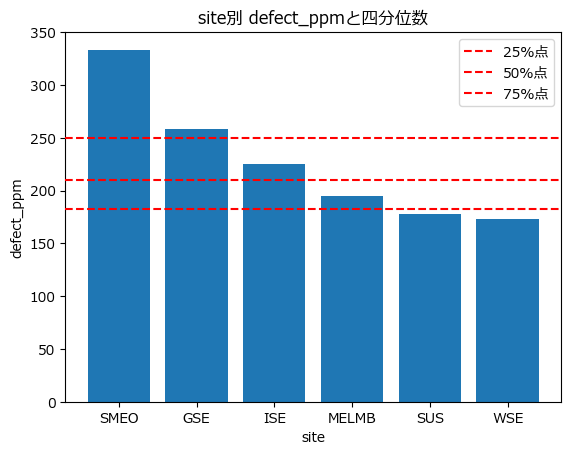

In [38]:
plt.bar(
    df_site_report["site"],
    df_site_report["defect_ppm"],
    zorder=1,
)
plt.axhline(
    q1,
    color="red",
    linestyle="--",
    label="25%点",
    zorder=10,
)

plt.axhline(
    q2,
    color="red",
    linestyle="--",
    label="50%点",
    zorder=10,
)

plt.axhline(
    q3,
    color="red",
    linestyle="--",
    label="75%点",
    zorder=10,
)
plt.title("site別 defect_ppmと四分位数")
plt.xlabel("site")
plt.ylabel("defect_ppm")
plt.legend()
plt.show()